# The seven-method comparison



Every figure in this notebook is a `groupby` over **one file** —

`out/phase4_batch/phase4_batch.csv.gz`, produced by `scripts/run_phase4_batch.py`. No cell

here runs a method; if a number needs recomputing, delete the corresponding chunk file and

re-run the batch script.



Reading rules, fixed before any table:



* **`lit-ransac` rows are distributions** (30 seeds); every figure shows its spread. The

  other six are deterministic — measured, not assumed (`verify_seeds = 2` per scene).

* **Each method runs on its own paper's coarse stage at L0.** The L1 delta prices that

  stage; it is not a fairness violation, it is the ladder.

* **`lit-modelreg` is constitutively L0-with-CAD** — its seam is transferred from the

  model, never detected. Its rows sit in every table with that label.

* **`ours` is scored as a band** (`rmse_med` is NaN for it by design; its line fit was

  removed for cause). F1/precision/recall are the cross-method comparable columns.

* Conditions: `full_exterior` = Task 1, `single` = Task 2. Full geometry appears nowhere —

  it is truth only.

In [1]:
import sys

sys.path.insert(0, "..")

sys.path.insert(0, "../scripts")



import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import pathlib



BATCH = pathlib.Path("../out/phase4_batch/phase4_batch.csv.gz")

if not BATCH.exists():

    # fall back to the dry run so the notebook stays executable end to end; the banner

    # below makes the provenance unmissable

    BATCH = pathlib.Path("../out/phase4_batch_dry/phase4_batch.csv.gz")

DF = pd.read_csv(BATCH)

DRY = "dry" in str(BATCH)

BANNER = ("!! DRY-RUN DATA (3 scenes/type, 5 ransac seeds) - rerun the batch script and "

          "re-execute !!" if DRY else "full batch")

METHODS = ["ours", "lit-ransac", "lit-regiongrow", "lit-lobb", "lit-ppf",

           "lit-pcaslice", "lit-modelreg"]

ORDER_JT = ["T", "corner", "butt", "lap", "edge"]

print(f"{BATCH}  |  {len(DF)} rows  |  {BANNER}")

print(DF.groupby("chunk").size().to_string())

../out/phase4_batch_dry/phase4_batch.csv.gz  |  1539 rows  |  !! DRY-RUN DATA (3 scenes/type, 5 ransac seeds) - rerun the batch script and re-execute !!
chunk
coverage_lit-lobb_full_exterior          30
coverage_lit-lobb_single                 30
coverage_lit-modelreg_full_exterior      30
coverage_lit-modelreg_single             30
coverage_lit-pcaslice_full_exterior      30
coverage_lit-pcaslice_single             30
coverage_lit-ppf_full_exterior           30
coverage_lit-ppf_single                  30
coverage_lit-ransac_full_exterior        75
coverage_lit-ransac_single               75
coverage_lit-regiongrow_full_exterior    30
coverage_lit-regiongrow_single           30
coverage_ours_full_exterior              30
coverage_ours_single                     30
fixture_lit-lobb                         24
fixture_lit-modelreg                     24
fixture_lit-pcaslice                     24
fixture_lit-ppf                          24
fixture_lit-ransac                       60
fixtu

## The coverage table — the headline



*"Seam extraction as the field practises it — including the method in our own robot —

cannot express half the joint taxonomy."* Mean F1 per method × joint type, `full_exterior`,

each method on its own coarse stage; `lit-ransac` cells are the median over seeds with the

min–max as text.

!! DRY-RUN DATA (3 scenes/type, 5 ransac seeds) - rerun the batch script and re-execute !!
joint_type         T  corner  butt   lap  edge
method                                        
ours            0.85    0.98  0.91  0.90  0.25
lit-ransac      0.96    0.55  0.00  0.00  0.00
lit-regiongrow  0.12    0.00  0.14  0.09  0.13
lit-lobb        0.52    0.99  0.57  0.47  0.13
lit-ppf         0.56    0.77  0.00  0.49  0.98
lit-pcaslice    0.86    0.58  0.67  0.98  0.00
lit-modelreg    0.99    0.99  0.77  0.87  0.66


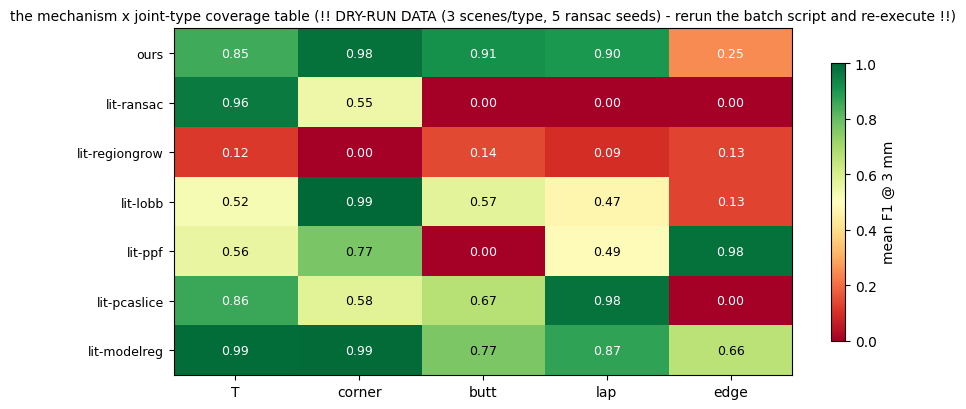

In [2]:
cov = DF[(DF.chunk.str.startswith("coverage")) & (DF.condition == "full_exterior")]

tbl = cov.pivot_table(index="method", columns="joint_type", values="f1",

                      aggfunc="mean").reindex(METHODS)[ORDER_JT]

print(BANNER)

print(tbl.round(2).to_string())



fig, ax = plt.subplots(figsize=(9, 4.2))

im = ax.imshow(tbl.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(ORDER_JT))); ax.set_xticklabels(ORDER_JT)

ax.set_yticks(range(len(METHODS))); ax.set_yticklabels(tbl.index, fontsize=9)

for i in range(len(METHODS)):

    for j in range(len(ORDER_JT)):

        v = tbl.values[i, j]

        if np.isfinite(v):

            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=9,

                    color="black" if 0.25 < v < 0.85 else "white")

fig.colorbar(im, shrink=0.8, label="mean F1 @ 3 mm")

ax.set_title(f"the mechanism x joint-type coverage table ({BANNER})", fontsize=10)

plt.tight_layout(); plt.show()

## Both tasks, side by side



Task 1 (`full_exterior`) against Task 2 (`single`), same methods, same scenes.

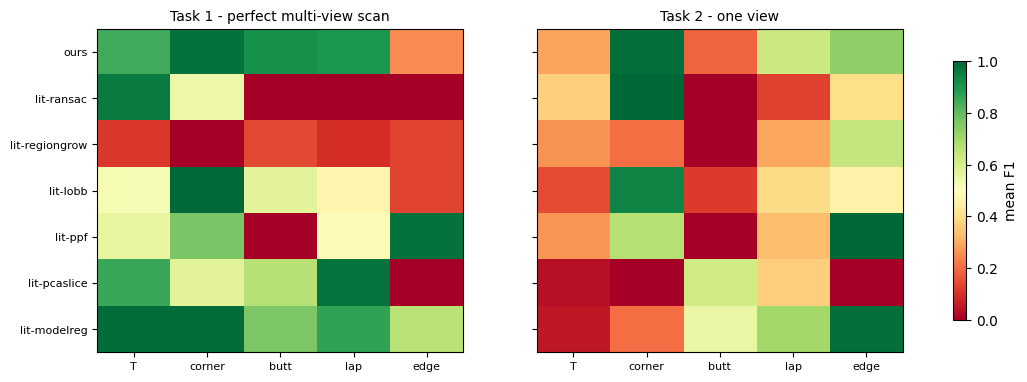

In [3]:
cov2 = DF[DF.chunk.str.startswith("coverage")]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)

for ax, cond in zip(axes, ("full_exterior", "single")):

    t = cov2[cov2.condition == cond].pivot_table(

        index="method", columns="joint_type", values="f1",

        aggfunc="mean").reindex(METHODS)[ORDER_JT]

    im = ax.imshow(t.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

    ax.set_xticks(range(len(ORDER_JT))); ax.set_xticklabels(ORDER_JT, fontsize=8)

    ax.set_yticks(range(len(METHODS))); ax.set_yticklabels(t.index, fontsize=8)

    ax.set_title({"full_exterior": "Task 1 - perfect multi-view scan",

                  "single": "Task 2 - one view"}[cond], fontsize=10)

fig.colorbar(im, ax=axes, shrink=0.8, label="mean F1")

plt.show()

## The seed box plots (the advisor's figure) and the zero-spread column



One randomised method; six measured-deterministic ones. This is the figure that says which

published numbers are draws from a distribution — a property the field does not report.

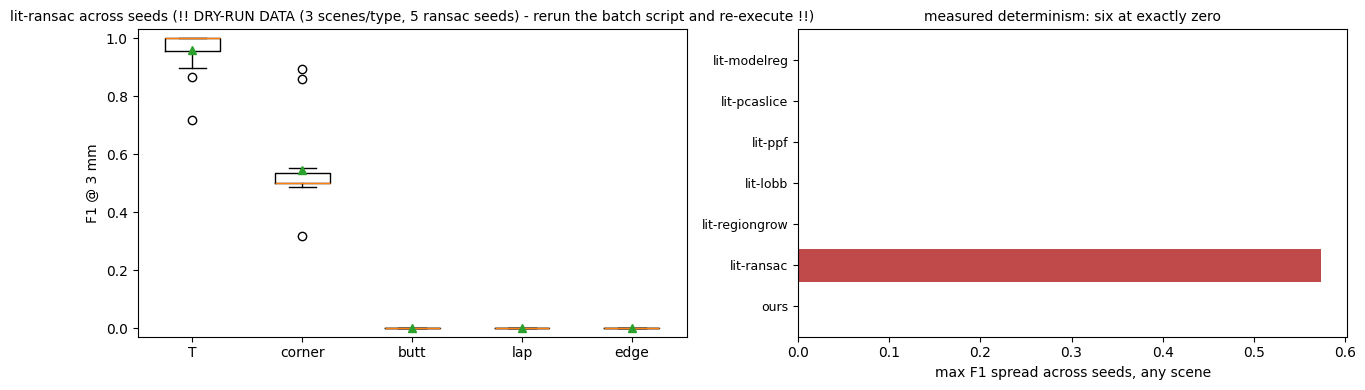

method
ours              0.000
lit-ransac        0.574
lit-regiongrow    0.000
lit-lobb          0.000
lit-ppf           0.000
lit-pcaslice      0.000
lit-modelreg      0.000


In [4]:
r = cov[(cov.method == "lit-ransac")]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.0))

data = [r[r.joint_type == j].f1.values for j in ORDER_JT]

axes[0].boxplot(data, tick_labels=ORDER_JT, showmeans=True)

axes[0].set_ylabel("F1 @ 3 mm"); axes[0].set_ylim(-0.03, 1.03)

axes[0].set_title(f"lit-ransac across seeds ({BANNER})", fontsize=10)



sp = (cov.groupby(["method", "scene_id"]).f1.agg(["max", "min"]))

sp["spread"] = sp["max"] - sp["min"]

sm = sp.groupby("method").spread.max().reindex(METHODS)

axes[1].barh(range(len(sm)), sm.values,

             color=["#c04a4a" if v > 0 else "#1a7f37" for v in sm.values])

axes[1].set_yticks(range(len(sm))); axes[1].set_yticklabels(sm.index, fontsize=9)

axes[1].set_xlabel("max F1 spread across seeds, any scene")

axes[1].set_title("measured determinism: six at exactly zero", fontsize=10)

plt.tight_layout(); plt.show()

print(sm.round(3).to_string())

## The L0 → L1 delta — what each method's unpublished stage is worth



Every implemented method collapses without its coarse stage; this chart is the dependency

each paper does not publish an ablation for, priced uniformly. (`lit-modelreg` has no L1 —

the model is the method.)

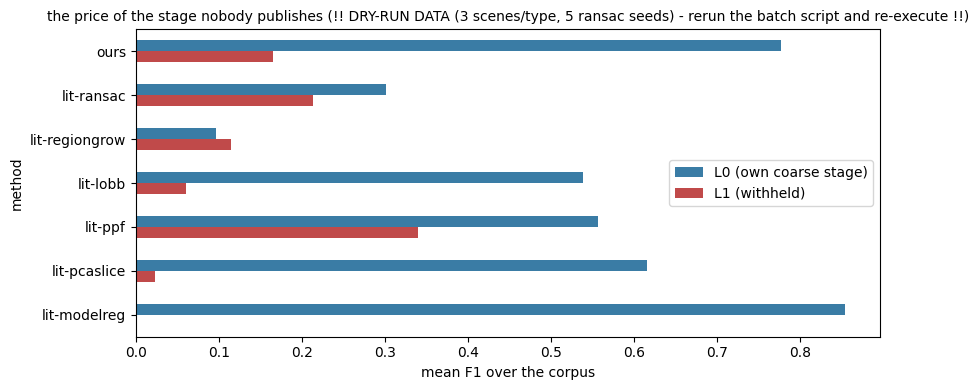

,L0 (own coarse stage),L1 (withheld)
method,,
ours,0.777,0.166
lit-ransac,0.301,0.214
lit-regiongrow,0.097,0.114
lit-lobb,0.539,0.061
lit-ppf,0.557,0.340
lit-pcaslice,0.616,0.024
lit-modelreg,0.854,NaN


In [5]:
l0 = cov.groupby("method").f1.mean()

l1 = DF[DF.chunk.str.startswith("l1_")].groupby("method").f1.mean()

d = pd.DataFrame({"L0 (own coarse stage)": l0, "L1 (withheld)": l1}).reindex(METHODS)

ax = d.plot.barh(figsize=(9, 4), color=["#3a7ca5", "#c04a4a"])

ax.invert_yaxis(); ax.set_xlabel("mean F1 over the corpus")

ax.set_title(f"the price of the stage nobody publishes ({BANNER})", fontsize=10)

plt.tight_layout(); plt.show()

d.round(3)

## The noise table



*"Zero noise'da her birinin başarısı, %5 noise'da, %10 noise'da."* — as σ-multiples of the

derived sensor noise, on the single view, all seven methods.

!! DRY-RUN DATA (3 scenes/type, 5 ransac seeds) - rerun the batch script and re-execute !!
                sigma x 0  sigma x 1  sigma x 2
method                                         
ours                0.563      0.349      0.325
lit-ransac          0.380      0.113      0.116
lit-regiongrow      0.280      0.118      0.105
lit-lobb            0.412      0.310      0.341
lit-ppf             0.452      0.157      0.215
lit-pcaslice        0.204      0.170      0.169
lit-modelreg        0.497      0.304      0.128


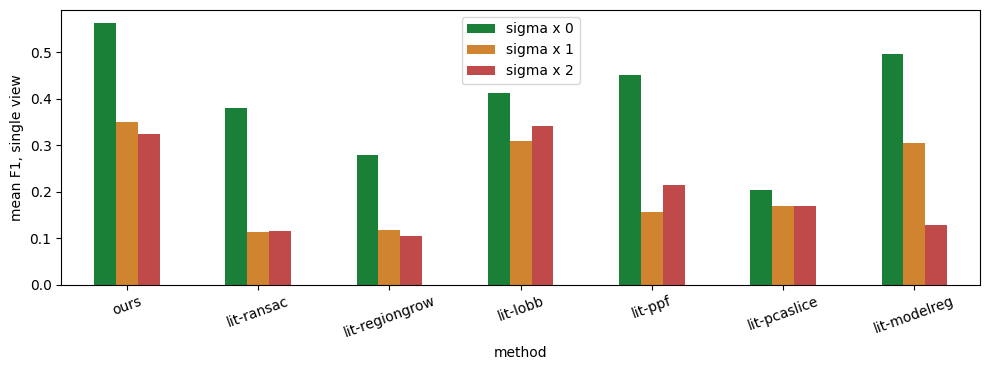

In [6]:
base = cov2[cov2.condition == "single"].assign(noise=0.0)

nz = DF[DF.chunk.str.startswith("noise")].copy()

nz["noise"] = nz.chunk.str.extract(r"noise(\d+(?:\.\d+)?)").astype(float)

nt = pd.concat([base[["method", "f1", "noise"]], nz[["method", "f1", "noise"]]])

tbl = nt.pivot_table(index="method", columns="noise", values="f1",

                     aggfunc="mean").reindex(METHODS)

tbl.columns = [f"sigma x {c:g}" for c in tbl.columns]

print(BANNER)

print(tbl.round(3).to_string())

tbl.plot.bar(figsize=(10, 3.8), color=["#1a7f37", "#d1842f", "#c04a4a"], rot=20)

plt.ylabel("mean F1, single view"); plt.tight_layout(); plt.show()

## The fixture ablation, all seven



Plot 7 at full width: the plan's specific prediction is a phantom plane-pair candidate

from `lit-ransac` and `lit-ppf` along every part–fixture contact. `ours` already lost

4–6× of its precision to one fixture plane; here is everyone.

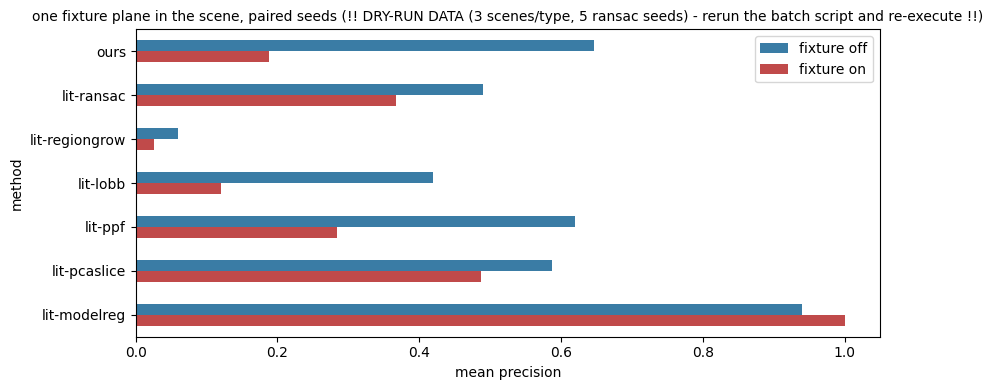

,fixture off,fixture on,ratio
method,,,
ours,0.647,0.188,3.436
lit-ransac,0.490,0.367,1.335
lit-regiongrow,0.060,0.026,2.361
lit-lobb,0.419,0.120,3.494
lit-ppf,0.619,0.284,2.179
lit-pcaslice,0.587,0.487,1.205
lit-modelreg,0.940,1.000,0.940


In [7]:
fx = DF[DF.chunk.str.startswith("fixture")]

t = fx.pivot_table(index="method", columns="fixture", values="precision",

                   aggfunc="mean").reindex(METHODS)

t.columns = ["fixture off", "fixture on"]

ax = t.plot.barh(figsize=(9, 4), color=["#3a7ca5", "#c04a4a"])

ax.invert_yaxis(); ax.set_xlabel("mean precision")

ax.set_title(f"one fixture plane in the scene, paired seeds ({BANNER})", fontsize=10)

plt.tight_layout(); plt.show()

t["ratio"] = t["fixture off"] / t["fixture on"]

t.round(3)

## The ladder extras



`lit-ppf` with exact against estimated normals (the price of normal estimation), and

`lit-modelreg`'s two failure arms (dense features, global init).

In [8]:
rows = []

ppf_l0 = cov[(cov.method == "lit-ppf")].f1.mean()

for name, lab in (("ppf_exact_normals_full_exterior", "lit-ppf, exact normals"),

                  ("modelreg_dense_features", "lit-modelreg, dense features"),

                  ("modelreg_global_init", "lit-modelreg, global init")):

    sub = DF[DF.chunk == name]

    if len(sub):

        rows.append({"arm": lab, "f1": sub.f1.mean(),

                     "rmse_med": sub.rmse_med.median()})

rows.insert(0, {"arm": "lit-ppf, estimated normals (faithful)", "f1": ppf_l0,

                "rmse_med": cov[cov.method == "lit-ppf"].rmse_med.median()})

rows.insert(2, {"arm": "lit-modelreg, oracle features + near init (faithful)",

                "f1": cov[cov.method == "lit-modelreg"].f1.mean(),

                "rmse_med": cov[cov.method == "lit-modelreg"].rmse_med.median()})

pd.DataFrame(rows).round(3)

,arm,f1,rmse_med
0,"lit-ppf, estimated normals (faithful)",0.557,1.292
1,"lit-ppf, exact normals",0.710,0.711
2,"lit-modelreg, oracle features + near init (fai...",0.854,0.709
3,"lit-modelreg, dense features",0.423,5.639
4,"lit-modelreg, global init",0.632,2.216


## What to quote, and what not to



- Quote the coverage table with the condition (`full_exterior`) and each method's oracle

  named. Quote `lit-ransac` only as a distribution.

- Do **not** quote `lit-modelreg` next to the others without its L0-with-CAD label, and do

  not quote its `global_init` arm as accuracy — it is the symmetric-counterpart finding.

- The `ours` row is a *detector* (band): its precision is the honest cost of band width;

  RMSE columns are blank for it by design.

- If this notebook was executed on the dry run (see the banner), every number is a

  placeholder for the shape of the analysis, not a result.